Imports

In [1]:
import numpy as np
np.random.seed(42)
import struct
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
DATA_PATH='Data/fashion-mnist'

#### Data processing

Load data

In [3]:
def load_mnist(images_path, labels_path):
    # Load labels
    with open(labels_path, 'rb') as lb:
        # Read header: magic number and number of labels
        _, num = struct.unpack(">II", lb.read(8))
        # Read labels as unsigned bytes
        labels = np.fromfile(lb, dtype=np.uint8)

    # Load images
    with open(images_path, 'rb') as img:
        # Read header: magic number, count, rows, cols
        _, num, rows, cols = struct.unpack(">IIII", img.read(16))
        # Read images into numpy array
        images = np.fromfile(img, dtype=np.uint8).reshape(num, rows, cols)

    return images, labels


In [4]:
X_train, y_train = load_mnist(
    f"{DATA_PATH}/train-images-idx3-ubyte",
    f"{DATA_PATH}/train-labels-idx1-ubyte"
)

X_test, y_test = load_mnist(
    f"{DATA_PATH}/t10k-images-idx3-ubyte",
    f"{DATA_PATH}/t10k-labels-idx1-ubyte"
)

In [5]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Flatten and Normalize

In [6]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

In [7]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 784) (60000,)
(10000, 784) (10000,)


Select data corresponding to classes 0, 1 and 2

In [8]:
classes = [0, 1, 2]

y_train_idx = [i for i in range(y_train.shape[0]) if y_train[i] in classes]
y_test_idx = [i for i in range(y_test.shape[0]) if y_test[i] in classes]

X_train = X_train[y_train_idx, :]
X_test = X_test[y_test_idx, :]
y_train = y_train[y_train_idx]
y_test = y_test[y_test_idx]

In [9]:
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_train.shape: (18000, 784)
y_train.shape: (18000,)
X_test.shape: (3000, 784)
y_test.shape: (3000,)


In [10]:
d = X_train.shape[1]
N_train = X_train.shape[0]
N_test = X_test.shape[0]

X = (N,d)

y = (N,)

d = 28x28 = 784

For train, N=18000

For test, N=3000

In [11]:
def plot_images(X, title, cols=5):
    num_images = len(X)
    rows = (num_images + cols - 1) // cols
    
    plt.figure(figsize=(cols*2, rows*2))
    if title:
        plt.suptitle(title)
    
    for i in range(num_images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show() 

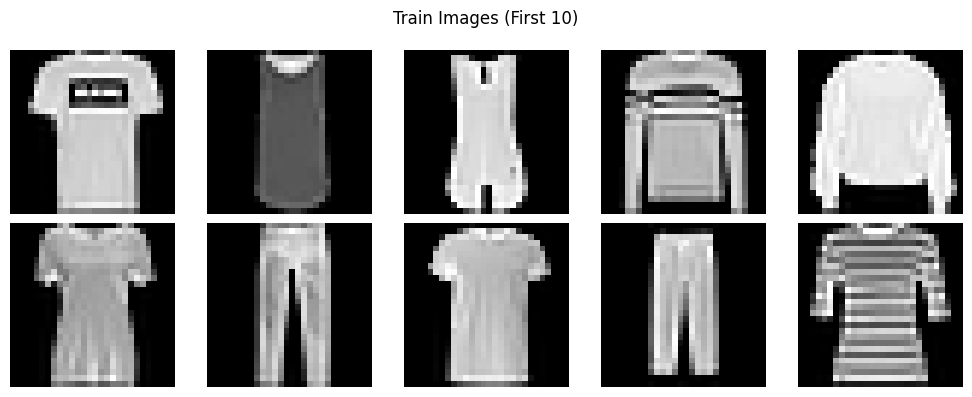

In [12]:
plot_images(X_train[:10],'Train Images (First 10)')

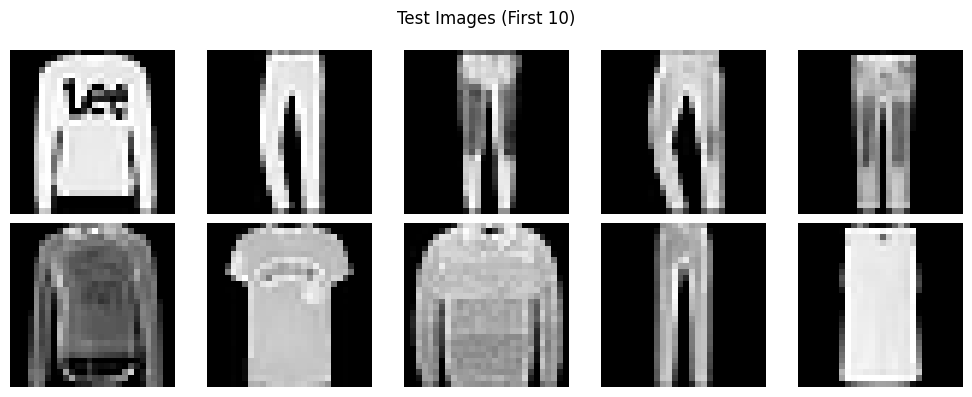

In [13]:
plot_images(X_test[:10],'Test Images (First 10)')

#### PCA implementation

Mean of the data:

$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$

Mean centered data:

$X_c = X - \mu$

Covariance matrix:

$S = \frac{X_c X_c^T}{N}$

Eigenvalue decomposition:

$S u_i = \lambda_i u_i$

Projection matrix using the top $p$ eigenvectors:

$U_p = [u_1, u_2, ..., u_p]$

Low dimensional representation:

$Y = U_p^T X_c$

In [14]:
def pca_fit(X,p):
    
    mu = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mu

    cov_matrix = 1/X.shape[0] * X_centered.T @ X_centered

    # Eigenvalue problem on covariance matrix
    eigvalues, eigvectors = np.linalg.eigh(cov_matrix)

    # sort eigenvectors in descending order of eigenvalues
    eig_idx = np.argsort(eigvalues)[::-1]      
    eigvalues = eigvalues[eig_idx]
    eigvectors = eigvectors[:, eig_idx] 

    eigenvectors_p = eigvectors[:, :p]

    return eigenvectors_p, mu
    
def pca_transform(X, eigenvectors_p, mu):
    return (X - mu) @ eigenvectors_p

In [15]:
# Apply PCA 
p = 10 
eigenvectors_p, mu = pca_fit(X_train, p)
X_train_pca = pca_transform(X_train, eigenvectors_p, mu) 
X_test_pca = pca_transform(X_test, eigenvectors_p, mu) 

print(f"PCA dimension of train data: {X_train_pca.shape[1]}") 
print(f"PCA dimension of test data: {X_test_pca.shape[1]}") 

PCA dimension of train data: 10
PCA dimension of test data: 10


In [16]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

#### Decision Stump (Regression)

We use a decision stump that splits the data based on a single feature.

The candidate thresholds are chosen as midpoints between consecutive sorted values:
$$
t = \frac{x_i + x_{i+1}}{2}
$$

The quality of a split is measured using the Sum of Squared Residuals (SSR):
$$
SSR = \sum_{i \in L} (y_i - \bar{y}_L)^2 + \sum_{i \in R} (y_i - \bar{y}_R)^2
$$

In [17]:
def compute_ssr(yL, yR):
    mean_L = np.mean(yL)
    mean_R = np.mean(yR)
    
    ssr = np.sum((yL - mean_L)**2) + np.sum((yR - mean_R)**2)
    return ssr, mean_L, mean_R

In [18]:
def get_best_stump(X, y, verbose=True):
    
    best_ssr = float('inf')
    best = None
    # Loop over all features 
    iterator = tqdm(range(X.shape[1])) if verbose else range(X.shape[1])
    for f in iterator:
        x = X[:, f]
        # Sort feature values
        sorted_idx = np.argsort(x)
        x_sorted = x[sorted_idx]
        y_sorted = y[sorted_idx]
        
        # Candidate thresholds = midpoints
        thresholds = (x_sorted[:-1] + x_sorted[1:]) / 2
        # Try each threhsold
        for t in thresholds:
            # Split data
            left = x <= t
            right = x > t
            # Skip invalid splits
            if np.sum(left) == 0 or np.sum(right) == 0:
                continue
            
            yL = y[left]
            yR = y[right]
            # Compute SSR
            ssr, mean_L, mean_R = compute_ssr(yL, yR)
    
            # Keep best split
            if ssr < best_ssr:
                best_ssr = ssr
                best = {
                    'f': f,
                    't': t,
                    'mean_L': mean_L,
                    'mean_R': mean_R
                }
    
    return best

#### Prediction using Decision Stump

The prediction for any sample is the mean response of the region it belongs to:
$$
\hat{y}(x) =
\begin{cases}
\bar{y}_L & \text{if } x \le t \\
\bar{y}_R & \text{if } x > t
\end{cases}
$$

In [19]:
def predict_stump(stump, X):
    preds = []
    
    for row in X:
        if row[stump['f']] <= stump['t']:
            preds.append(stump['mean_L'])
        else:
            preds.append(stump['mean_R'])
    
    return np.array(preds)

#### Train single stump

In [20]:
stump = get_best_stump(X_train_pca, y_train, verbose=True)

print(f"Best Stump: feature {stump['f']} | threshold {stump['t']:.4f}")

preds = predict_stump(stump, X_test_pca)
print(f"Test MSE (Single Stump): {mse(y_test, preds):.4f}")

100%|██████████| 10/10 [00:28<00:00,  2.86s/it]

Best Stump: feature 2 | threshold 1.4508
Test MSE (Single Stump): 0.3629


#### Bagging(Regression) and Out-of-Bag Error

We train multiple decision stumps on bootstrap samples and aggregate predictions.

The bagging prediction is computed as:
$$
\hat{y}(x) = \frac{1}{B} \sum_{i=1}^{B} h_i(x)
$$

Out-of-Bag (OOB) samples are used to estimate the generalization error using MSE.

In [21]:
def bagging_regression(X, y, X_test, n_models=5):
    all_preds = []
    total_oob_error = 0
    total_oob_samples = 0
    # Build mulitple trees (5)
    for _ in tqdm(range(n_models)):
        # Bootstrap sampling with replacement
        idx = np.random.choice(len(X), len(X), replace=True)
        # Find OOB samples
        oob_mask = np.ones(len(X), dtype=bool)
        oob_mask[idx] = False
        oob_idx = np.where(oob_mask)[0]
        # Train decision stump
        stump = get_best_stump(X[idx], y[idx], verbose=False)
        # OOB error (MSE)
        if len(oob_idx) > 0:
            oob_preds = predict_stump(stump, X[oob_idx])
            total_oob_error += np.sum((oob_preds - y[oob_idx])**2)
            total_oob_samples += len(oob_idx)
        # Store test predictions
        all_preds.append(predict_stump(stump, X_test))
    
    # Average predictions across all trees
    final_preds = np.mean(np.array(all_preds), axis=0)
    # Average OOB error across all trees
    avg_oob = total_oob_error / total_oob_samples if total_oob_samples > 0 else 0
    
    return final_preds, avg_oob

#### Run Bagging

In [22]:
bag_preds, bag_oob = bagging_regression(X_train_pca, y_train, X_test_pca)

print(f"OOB MSE (Bagging): {bag_oob:.4f}")
print(f"Test MSE (Bagging): {mse(y_test, bag_preds):.4f}")

100%|██████████| 5/5 [02:23<00:00, 28.77s/it]

OOB MSE (Bagging): 0.3446
Test MSE (Bagging): 0.3588


#### Comparison of Predictions

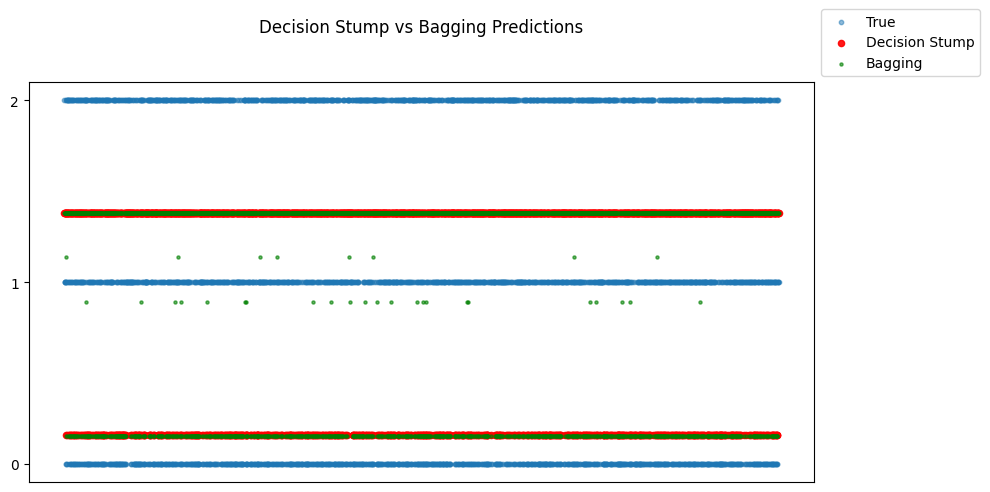

In [23]:
plt.figure(figsize=(10,5))

x = np.arange(len(y_test))

plt.scatter(x, y_test, alpha=0.5, s=10, label='True')
plt.scatter(x, preds, alpha=0.9, s=20, label='Decision Stump', color='red')
plt.scatter(x, bag_preds, alpha=0.6, s=5, label='Bagging', marker='o', color='green')

plt.title("Decision Stump vs Bagging Predictions\n\n")

plt.xticks([])

plt.yticks([0,1,2])

plt.legend(loc='upper left', bbox_to_anchor=(1,1.2))

plt.tight_layout()
plt.show()

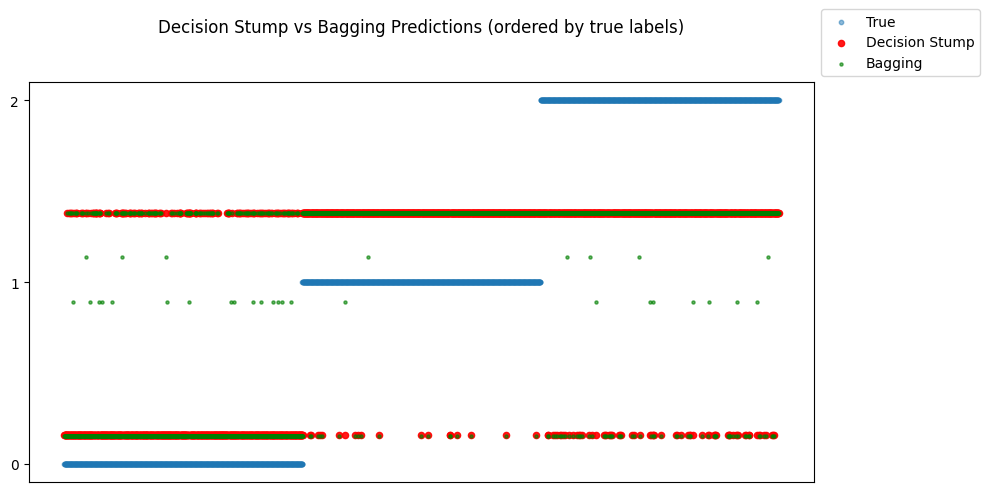

In [34]:
idx = np.argsort(y_test)

y_sorted = y_test[idx]
preds_sorted = preds[idx]
bag_preds_sorted = bag_preds[idx]

x = np.arange(len(y_sorted)) 

plt.figure(figsize=(10,5))

plt.scatter(x, y_sorted, alpha=0.5, s=10, label='True')
plt.scatter(x, preds_sorted, alpha=0.9, s=20, label='Decision Stump', color='red')
plt.scatter(x, bag_preds_sorted, alpha=0.6, s=5, label='Bagging', marker='o', color='green')

plt.title("Decision Stump vs Bagging Predictions (ordered by true labels)\n\n")

plt.xticks([])
plt.yticks([0,1,2])

plt.legend(loc='upper left', bbox_to_anchor=(1,1.2))

plt.tight_layout()
plt.show()